# EDA: Feature Attribution Rules for LLM Analyst

**Goal:** Find the strongest drivers of salary deviations from per-category baselines.  
These rules will feed dynamic context into the LLM prompts so narratives cite the *actual* primary driver.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

# Load raw dataset
df = pd.read_csv("data/ds_salaries.csv")

# Load feature mappings to engineer the same features the model uses
mappings = joblib.load("model/feature_mappings.joblib")
job_map = mappings["job_category_map"]
tier_map = mappings["country_tier_map"]

# Engineer features
df["job_category"] = df["job_title"].map(job_map)
df["location_tier"] = df["company_location"].map(tier_map)
df["is_same_country"] = (df["company_location"] == df["employee_residence"]).astype(int)

print(f"Dataset: {df.shape[0]} rows")
print(f"Job categories: {df['job_category'].unique()}")
print(f"Location tiers: {df['location_tier'].unique()}")
df[["job_category", "experience_level", "company_size", "location_tier", "remote_ratio", "is_same_country", "salary_in_usd"]].head()

Dataset: 607 rows
Job categories: <StringArray>
['Data Scientist', 'Machine Learning Engineer', 'Data Engineer',
 'Data Analyst']
Length: 4, dtype: str
Location tiers: <StringArray>
['High_Tier', 'Low_Tier', 'Mid_Tier']
Length: 3, dtype: str


,job_category,experience_level,company_size,location_tier,remote_ratio,is_same_country,salary_in_usd
0,Data Scientist,MI,L,High_Tier,0,1,79833
1,Machine Learning Engineer,SE,S,High_Tier,0,1,260000
2,Data Engineer,SE,M,High_Tier,50,1,109024
3,Data Analyst,MI,S,Low_Tier,0,1,20000
4,Machine Learning Engineer,SE,L,High_Tier,50,1,150000


## Step 2: Establish Baselines

Median `salary_in_usd` per `job_category` — this is the reference point for all deviation analysis.

In [2]:
# Baseline: median salary per job category
baselines = df.groupby("job_category")["salary_in_usd"].median()
print("Per-category baseline medians:")
print(baselines.to_string())
print(f"\nOverall median: ${df['salary_in_usd'].median():,.0f}")

# Add baseline and deviation columns to the dataframe
df["baseline_median"] = df["job_category"].map(baselines)
df["pct_deviation"] = ((df["salary_in_usd"] - df["baseline_median"]) / df["baseline_median"]) * 100

# Quick sanity check
print(f"\nDeviation stats:")
print(df["pct_deviation"].describe().to_string())

Per-category baseline medians:
job_category
Data Analyst                  92000.0
Data Engineer                111887.5
Data Scientist               110000.0
Machine Learning Engineer     81872.0

Overall median: $101,570

Deviation stats:
count    607.000000
mean       9.822308
std       70.012681
min      -97.400909
25%      -37.649055
50%        0.000000
75%       43.052655
max      436.252933


## Step 3: Analyze Deviations

### 3.1 Experience Level

Experience Level — % Deviation from Category Baseline:
                  mean_dev_%  median_dev_%    n
experience_level                               
EN                -36.243270    -43.710012   88
MI                -13.349749    -26.240197  213
SE                 35.071933     29.529215  280
EX                 83.650146     59.725292   26


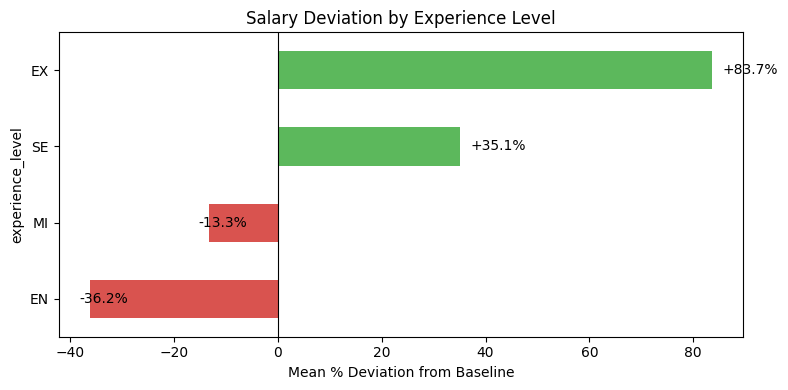

In [3]:
exp_dev = df.groupby("experience_level")["pct_deviation"].agg(["mean", "median", "count"])
exp_dev.columns = ["mean_dev_%", "median_dev_%", "n"]
exp_dev = exp_dev.reindex(["EN", "MI", "SE", "EX"])
print("Experience Level — % Deviation from Category Baseline:")
print(exp_dev.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#d9534f" if v < 0 else "#5cb85c" for v in exp_dev["mean_dev_%"]]
exp_dev["mean_dev_%"].plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("Mean % Deviation from Baseline")
ax.set_title("Salary Deviation by Experience Level")
ax.axvline(0, color="black", linewidth=0.8)
for i, v in enumerate(exp_dev["mean_dev_%"]):
    ax.text(v + (2 if v >= 0 else -2), i, f"{v:+.1f}%", va="center", fontsize=10)
plt.tight_layout()
plt.show()

### 3.2 Location Tier

Location Tier — % Deviation from Category Baseline:
               mean_dev_%  median_dev_%    n
location_tier                               
High_Tier       26.445120     16.924552  488
Mid_Tier       -46.368884    -48.797500   70
Low_Tier       -75.454202    -78.260870   49


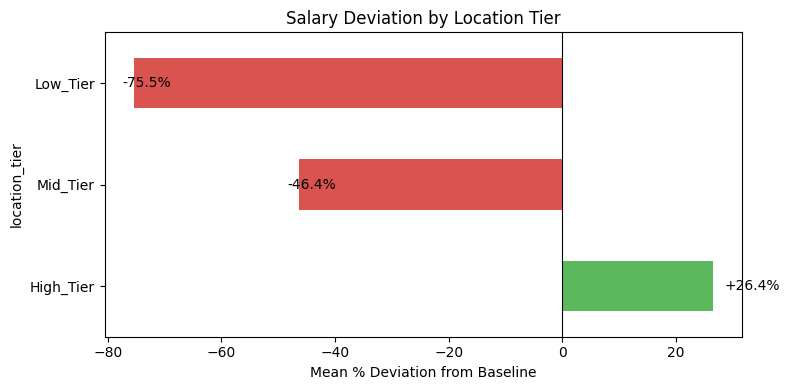

In [4]:
tier_dev = df.groupby("location_tier")["pct_deviation"].agg(["mean", "median", "count"])
tier_dev.columns = ["mean_dev_%", "median_dev_%", "n"]
tier_dev = tier_dev.reindex(["High_Tier", "Mid_Tier", "Low_Tier"])
print("Location Tier — % Deviation from Category Baseline:")
print(tier_dev.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#d9534f" if v < 0 else "#5cb85c" for v in tier_dev["mean_dev_%"]]
tier_dev["mean_dev_%"].plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("Mean % Deviation from Baseline")
ax.set_title("Salary Deviation by Location Tier")
ax.axvline(0, color="black", linewidth=0.8)
for i, v in enumerate(tier_dev["mean_dev_%"]):
    ax.text(v + (2 if v >= 0 else -2), i, f"{v:+.1f}%", va="center", fontsize=10)
plt.tight_layout()
plt.show()

### 3.3 Company Size Penalty (SE/EX at Small vs Large)

Mean % Deviation by Experience Level x Company Size:
company_size         S     M      L
experience_level                   
EN               -33.3 -49.4  -25.6
MI               -47.0 -12.9   -2.5
SE                19.7  34.1   42.4
EX                82.4  63.9  105.5

--- Senior/Executive Size Penalty ---
SE: Small=$108,604 (n=22) vs Large=$147,000 (n=72) → -26.1% gap
EX: Small=$118,187 (n=3) vs Large=$196,979 (n=11) → -40.0% gap


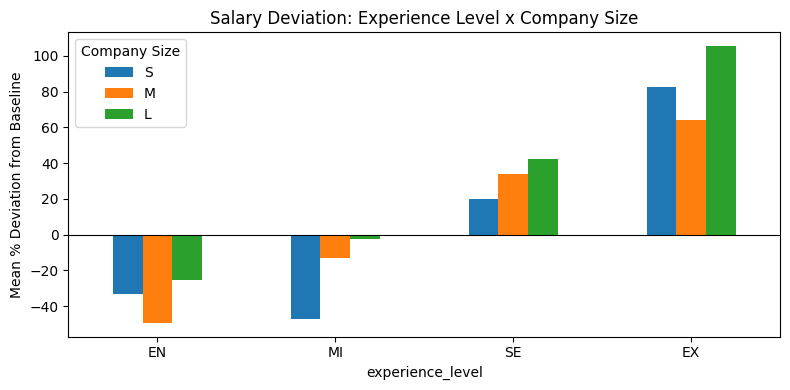

In [5]:
# Company size deviation for all experience levels
size_exp = df.groupby(["experience_level", "company_size"])["pct_deviation"].mean().unstack()
size_exp = size_exp.reindex(index=["EN", "MI", "SE", "EX"], columns=["S", "M", "L"])
print("Mean % Deviation by Experience Level x Company Size:")
print(size_exp.round(1).to_string())

# Focus: SE/EX penalty at Small vs Large
print("\n--- Senior/Executive Size Penalty ---")
for exp in ["SE", "EX"]:
    senior = df[df["experience_level"] == exp]
    small_med = senior[senior["company_size"] == "S"]["salary_in_usd"].median()
    large_med = senior[senior["company_size"] == "L"]["salary_in_usd"].median()
    n_s = len(senior[senior["company_size"] == "S"])
    n_l = len(senior[senior["company_size"] == "L"])
    if large_med > 0:
        penalty = ((small_med - large_med) / large_med) * 100
        print(f"{exp}: Small=${small_med:,.0f} (n={n_s}) vs Large=${large_med:,.0f} (n={n_l}) → {penalty:+.1f}% gap")

fig, ax = plt.subplots(figsize=(8, 4))
size_exp.plot(kind="bar", ax=ax)
ax.set_ylabel("Mean % Deviation from Baseline")
ax.set_title("Salary Deviation: Experience Level x Company Size")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend(title="Company Size")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 3.4 International Remote (is_same_country)

International vs Same Country — % Deviation:
                              mean_dev_%  median_dev_%    n
is_same_country                                            
International (diff country)  -23.280695    -42.976364   51
Same country                   12.858734      3.663633  556

--- Median Salary ---
  Same country: $105,200 (n=556)
  International: $61,467 (n=51)


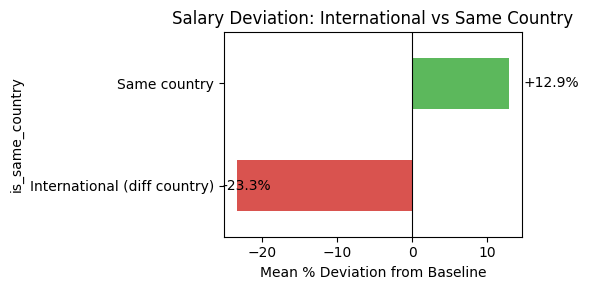

In [6]:
intl_dev = df.groupby("is_same_country")["pct_deviation"].agg(["mean", "median", "count"])
intl_dev.columns = ["mean_dev_%", "median_dev_%", "n"]
intl_dev.index = intl_dev.index.map({0: "International (diff country)", 1: "Same country"})
print("International vs Same Country — % Deviation:")
print(intl_dev.to_string())

# Salary comparison
print("\n--- Median Salary ---")
for val, label in [(1, "Same country"), (0, "International")]:
    subset = df[df["is_same_country"] == val]
    print(f"  {label}: ${subset['salary_in_usd'].median():,.0f} (n={len(subset)})")

fig, ax = plt.subplots(figsize=(6, 3))
colors = ["#d9534f" if v < 0 else "#5cb85c" for v in intl_dev["mean_dev_%"]]
intl_dev["mean_dev_%"].plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("Mean % Deviation from Baseline")
ax.set_title("Salary Deviation: International vs Same Country")
ax.axvline(0, color="black", linewidth=0.8)
for i, v in enumerate(intl_dev["mean_dev_%"]):
    ax.text(v + (2 if v >= 0 else -2), i, f"{v:+.1f}%", va="center", fontsize=10)
plt.tight_layout()
plt.show()

### 3.5 Remote Ratio

Remote Ratio — % Deviation from Category Baseline:
              mean_dev_%  median_dev_%    n
remote_ratio                               
0               3.335066     -7.181818  127
50            -18.298754    -32.721739   99
100            19.291769     14.130435  381


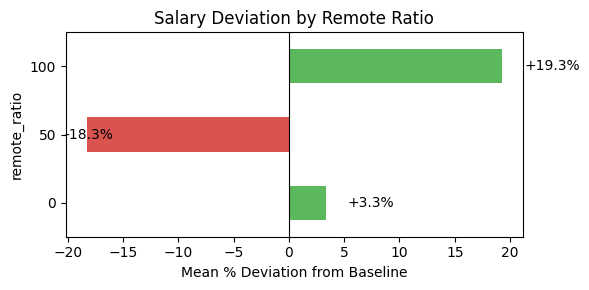

In [7]:
remote_dev = df.groupby("remote_ratio")["pct_deviation"].agg(["mean", "median", "count"])
remote_dev.columns = ["mean_dev_%", "median_dev_%", "n"]
print("Remote Ratio — % Deviation from Category Baseline:")
print(remote_dev.to_string())

fig, ax = plt.subplots(figsize=(6, 3))
colors = ["#d9534f" if v < 0 else "#5cb85c" for v in remote_dev["mean_dev_%"]]
remote_dev["mean_dev_%"].plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("Mean % Deviation from Baseline")
ax.set_title("Salary Deviation by Remote Ratio")
ax.axvline(0, color="black", linewidth=0.8)
for i, v in enumerate(remote_dev["mean_dev_%"]):
    ax.text(v + (2 if v >= 0 else -2), i, f"{v:+.1f}%", va="center", fontsize=10)
plt.tight_layout()
plt.show()

### 3.6 Summary: Deviation Magnitudes (All Features Side-by-Side)

All Feature Deviations Ranked (strongest negative → strongest positive):
       feature  mean_dev_%
      Low_Tier  -75.454202
      Mid_Tier  -46.368884
    EN (Entry)  -36.243270
 International  -23.280695
    Remote 50%  -18.298754
      MI (Mid)  -13.349749
     Remote 0%    3.335066
  Same country   12.858734
   Remote 100%   19.291769
     High_Tier   26.445120
   SE (Senior)   35.071933
EX (Executive)   83.650146


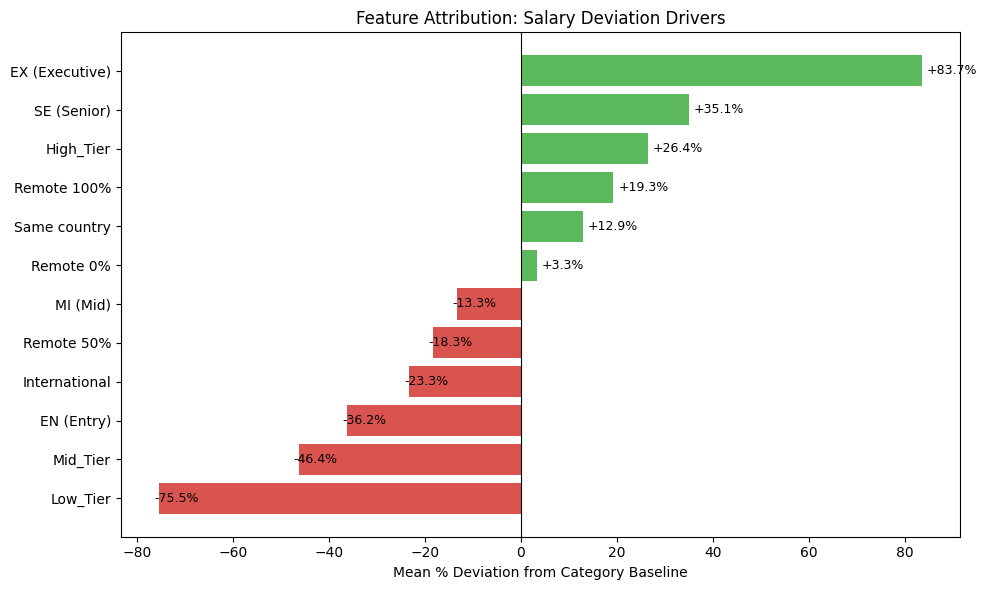

In [8]:
# Combine all deviations for ranking
summary = pd.DataFrame({
    "feature": [
        "EX (Executive)", "SE (Senior)", "MI (Mid)", "EN (Entry)",
        "High_Tier", "Mid_Tier", "Low_Tier",
        "Same country", "International",
        "Remote 100%", "Remote 50%", "Remote 0%",
    ],
    "mean_dev_%": [
        exp_dev.loc["EX", "mean_dev_%"], exp_dev.loc["SE", "mean_dev_%"],
        exp_dev.loc["MI", "mean_dev_%"], exp_dev.loc["EN", "mean_dev_%"],
        tier_dev.loc["High_Tier", "mean_dev_%"], tier_dev.loc["Mid_Tier", "mean_dev_%"],
        tier_dev.loc["Low_Tier", "mean_dev_%"],
        intl_dev.loc["Same country", "mean_dev_%"],
        intl_dev.loc["International (diff country)", "mean_dev_%"],
        remote_dev.loc[100, "mean_dev_%"], remote_dev.loc[50, "mean_dev_%"],
        remote_dev.loc[0, "mean_dev_%"],
    ]
})

summary = summary.sort_values("mean_dev_%", ascending=True)
print("All Feature Deviations Ranked (strongest negative → strongest positive):")
print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#d9534f" if v < 0 else "#5cb85c" for v in summary["mean_dev_%"]]
ax.barh(summary["feature"], summary["mean_dev_%"], color=colors)
ax.set_xlabel("Mean % Deviation from Category Baseline")
ax.set_title("Feature Attribution: Salary Deviation Drivers")
ax.axvline(0, color="black", linewidth=0.8)
for i, (_, row) in enumerate(summary.iterrows()):
    v = row["mean_dev_%"]
    ax.text(v + (1 if v >= 0 else -1), i, f"{v:+.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## Step 4: Extract Python Logic — `determine_primary_driver`

**Findings ranked by absolute deviation magnitude:**

| Driver | Mean Deviation | Direction |
|--------|---------------|-----------|
| EX (Executive) | +83.7% | Strongest positive |
| Low_Tier geography | -75.5% | Strongest negative |
| Mid_Tier geography | -46.4% | Strong negative |
| EN (Entry-level) | -36.2% | Strong negative |
| SE (Senior) | +35.1% | Positive |
| High_Tier geography | +26.4% | Positive |
| EX at Small company | -40.0% vs Large | Interaction penalty |
| SE at Small company | -26.1% vs Large | Interaction penalty |
| International remote | -23.3% | Moderate negative |
| Remote 100% | +19.3% | Moderate positive |

**Priority logic tree:**
1. Entry-level (EN) below → experience is the primary drag
2. Executive (EX) above → seniority premium
3. Low/Mid tier below → geographic pay gap
4. High tier above → high-tier geography premium
5. Senior at Small below → company size penalty
6. International → cross-border discount
7. Fallback → general market positioning

In [9]:
def determine_primary_driver(combo: dict, status: str) -> str:
    """
    Determine the primary driver of a salary prediction's deviation from
    the market baseline, based on EDA-derived feature attribution rules.

    Parameters
    ----------
    combo : dict
        The input combination dict with keys: experience_level, location_tier,
        company_size, is_same_country, remote_ratio.
    status : str
        "ABOVE" or "BELOW" — the pre-calculated position vs market median.

    Returns
    -------
    str
        A phrase completing: "This positioning is primarily driven by [X]."
    """
    exp = combo.get("experience_level", "")
    tier = combo.get("location_tier", "")
    size = combo.get("company_size", "")
    same = combo.get("is_same_country", 1)
    remote = combo.get("remote_ratio", 50)

    # ── Priority 1: Entry-level is the strongest negative drag (-36%) ─────
    if exp == "EN" and status == "BELOW":
        return "entry-level experience, which averages 36% below category baselines"

    # ── Priority 2: Executive seniority premium (+84%) ────────────────────
    if exp == "EX" and status == "ABOVE":
        return "executive-level seniority, which commands an 84% premium over category baselines"

    # ── Priority 3: Low/Mid-tier geography penalty (-75% / -46%) ──────────
    if tier == "Low_Tier" and status == "BELOW":
        return "the low-tier geographic market, where salaries average 75% below global baselines"

    if tier == "Mid_Tier" and status == "BELOW":
        return "the mid-tier geographic market, where salaries average 46% below global baselines"

    # ── Priority 4: High-tier geography premium (+26%) ────────────────────
    if tier == "High_Tier" and status == "ABOVE":
        return "the high-tier geographic market, which sustains a 26% premium over global baselines"

    # ── Priority 5: Senior/Executive at Small company penalty ─────────────
    if exp in ("SE", "EX") and size == "S" and status == "BELOW":
        pct = "40%" if exp == "EX" else "26%"
        return f"the small-company size penalty, where {exp}-level roles earn {pct} less than at large firms"

    # ── Priority 6: International cross-border discount (-23%) ────────────
    if same == 0 and status == "BELOW":
        return "the international cross-border arrangement, which averages 23% below domestic roles"

    # ── Priority 7: Fallback — general market positioning ─────────────────
    if status == "ABOVE":
        return "a combination of seniority, geography, and company scale favoring above-market compensation"
    return "a combination of experience level, geographic market, and company characteristics"


# ── Test the function ─────────────────────────────────────────────────────────
test_cases = [
    ({"experience_level": "EN", "location_tier": "High_Tier", "company_size": "S", "is_same_country": 1, "remote_ratio": 0}, "BELOW"),
    ({"experience_level": "EX", "location_tier": "High_Tier", "company_size": "L", "is_same_country": 1, "remote_ratio": 100}, "ABOVE"),
    ({"experience_level": "SE", "location_tier": "Low_Tier", "company_size": "M", "is_same_country": 1, "remote_ratio": 50}, "BELOW"),
    ({"experience_level": "MI", "location_tier": "High_Tier", "company_size": "L", "is_same_country": 0, "remote_ratio": 100}, "BELOW"),
    ({"experience_level": "SE", "location_tier": "High_Tier", "company_size": "S", "is_same_country": 1, "remote_ratio": 50}, "BELOW"),
    ({"experience_level": "SE", "location_tier": "High_Tier", "company_size": "L", "is_same_country": 1, "remote_ratio": 100}, "ABOVE"),
]

print("Test cases:")
for combo, status in test_cases:
    driver = determine_primary_driver(combo, status)
    label = f"{combo['experience_level']} | {combo['location_tier']} | {combo['company_size']} | same={combo['is_same_country']}"
    print(f"  [{status:5s}] {label}")
    print(f"         → This positioning is primarily driven by {driver}.")
    print()

Test cases:
  [BELOW] EN | High_Tier | S | same=1
         → This positioning is primarily driven by entry-level experience, which averages 36% below category baselines.

  [ABOVE] EX | High_Tier | L | same=1
         → This positioning is primarily driven by executive-level seniority, which commands an 84% premium over category baselines.

  [BELOW] SE | Low_Tier | M | same=1
         → This positioning is primarily driven by the low-tier geographic market, where salaries average 75% below global baselines.

  [BELOW] MI | High_Tier | L | same=0
         → This positioning is primarily driven by the international cross-border arrangement, which averages 23% below domestic roles.

  [BELOW] SE | High_Tier | S | same=1
         → This positioning is primarily driven by the small-company size penalty, where SE-level roles earn 26% less than at large firms.

  [ABOVE] SE | High_Tier | L | same=1
         → This positioning is primarily driven by the high-tier geographic market, which sust

## Step 5: Data-Driven Per-Category Thresholds via Percentiles

Replace global averaged thresholds with **per-category** boundaries, since the
salary distributions differ significantly across job categories (e.g. MLE P90
is +153% vs Data Analyst P90 at +63%).

**Method:**
1. Compute P10, P40, P50 (median), P60, P90 for each category.
2. Express each percentile as a % deviation from the category median.
3. Store per-category thresholds in a dict — each category gets its own boundaries.
4. "On Par" = middle 20% of the distribution (P40→P60).

Salary Percentiles by Job Category (P10 / P40 / P50 / P60 / P90):
                               P10      P40       P50       P60       P90
job_category                                                             
Data Analyst               $36,559  $82,960   $92,000  $105,240  $150,068
Data Engineer              $46,853  $98,158  $111,888  $132,320  $200,000
Data Scientist             $38,873  $93,064  $110,000  $131,021  $210,000
Machine Learning Engineer  $20,922  $70,000   $81,872   $98,158  $207,000


/tmp/ipykernel_1462065/1227867599.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(plot_data, labels=short_labels, patch_artist=True, showmeans=True)


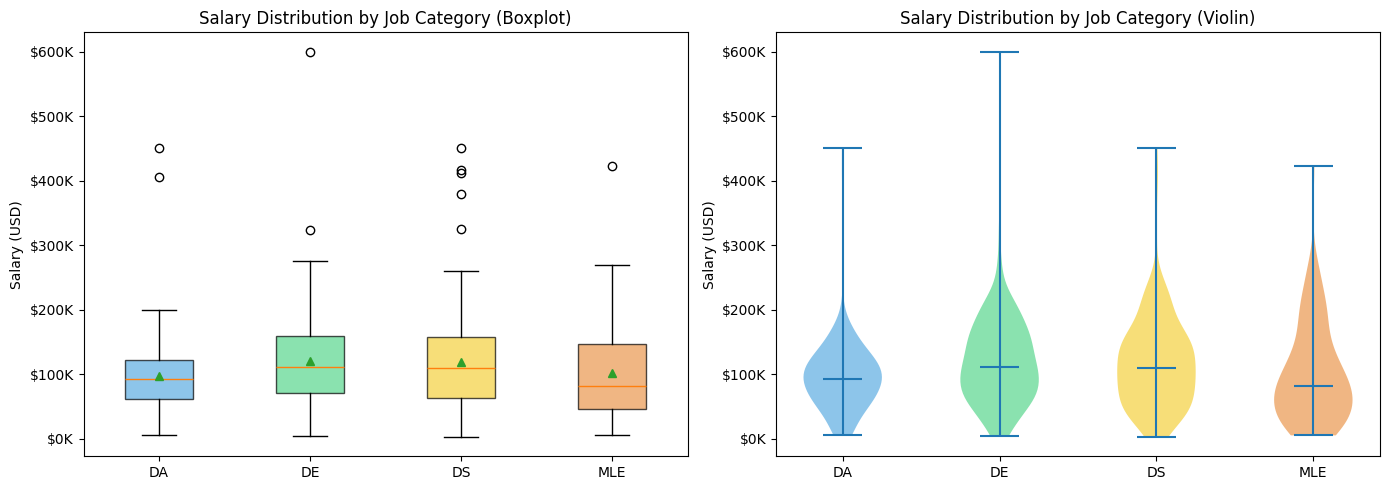

In [10]:
# ── 5.1 Percentile Distribution per Job Category ────────────────────────────
percentiles = [10, 40, 50, 60, 90]
pct_table = df.groupby("job_category")["salary_in_usd"].quantile(
    [p / 100 for p in percentiles]
).unstack()
pct_table.columns = [f"P{p}" for p in percentiles]

print("Salary Percentiles by Job Category (P10 / P40 / P50 / P60 / P90):")
print(pct_table.map(lambda x: f"${x:,.0f}").to_string())

# ── Boxplots + Violin plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

categories_ordered = ["Data Analyst", "Data Engineer", "Data Scientist", "Machine Learning Engineer"]
plot_data = [df[df["job_category"] == cat]["salary_in_usd"] for cat in categories_ordered]
short_labels = ["DA", "DE", "DS", "MLE"]

# Boxplot
bp = axes[0].boxplot(plot_data, labels=short_labels, patch_artist=True, showmeans=True)
for patch, color in zip(bp["boxes"], ["#5dade2", "#58d68d", "#f4d03f", "#eb984e"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel("Salary (USD)")
axes[0].set_title("Salary Distribution by Job Category (Boxplot)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))

# Violin plot
vp = axes[1].violinplot(plot_data, showmedians=True, showextrema=True)
for i, body in enumerate(vp["bodies"]):
    body.set_facecolor(["#5dade2", "#58d68d", "#f4d03f", "#eb984e"][i])
    body.set_alpha(0.7)
axes[1].set_xticks(range(1, 5))
axes[1].set_xticklabels(short_labels)
axes[1].set_ylabel("Salary (USD)")
axes[1].set_title("Salary Distribution by Job Category (Violin)")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))

plt.tight_layout()
plt.show()

In [11]:
# ── 5.2 Per-Category Percentage Deviation from Median ────────────────────────
dev_table = pd.DataFrame(index=pct_table.index)
for p in ["P10", "P40", "P60", "P90"]:
    dev_table[f"{p}_dev_%"] = ((pct_table[p] - pct_table["P50"]) / pct_table["P50"]) * 100

print("Percentile Deviation from Median (%) — Per Category:")
print(dev_table.round(1).to_string())

# ── Per-category thresholds dict ─────────────────────────────────────────────
print("\n" + "=" * 70)
print("PER-CATEGORY THRESHOLDS (P10, P40, P60, P90 as % from median):")
print("=" * 70)
print("\nCATEGORY_THRESHOLDS = {")
for cat in sorted(dev_table.index):
    p10 = round(dev_table.loc[cat, "P10_dev_%"])
    p40 = round(dev_table.loc[cat, "P40_dev_%"])
    p60 = round(dev_table.loc[cat, "P60_dev_%"])
    p90 = round(dev_table.loc[cat, "P90_dev_%"])
    print(f'    "{cat}": ({p10}, {p40}, {p60}, {p90}),')
print("}")

# ── Show the spread to justify per-category over global average ──────────────
print("\n--- Why per-category? (spread across categories) ---")
avg_devs = dev_table.mean()
for col in dev_table.columns:
    vals = dev_table[col]
    print(f"  {col:12s}: avg={avg_devs[col]:+.1f}%  min={vals.min():+.1f}%  max={vals.max():+.1f}%  spread={vals.max()-vals.min():.0f}pp")

Percentile Deviation from Median (%) — Per Category:
                           P10_dev_%  P40_dev_%  P60_dev_%  P90_dev_%
job_category                                                         
Data Analyst                   -60.3       -9.8       14.4       63.1
Data Engineer                  -58.1      -12.3       18.3       78.8
Data Scientist                 -64.7      -15.4       19.1       90.9
Machine Learning Engineer      -74.4      -14.5       19.9      152.8

PER-CATEGORY THRESHOLDS (P10, P40, P60, P90 as % from median):

CATEGORY_THRESHOLDS = {
    "Data Analyst": (-60, -10, 14, 63),
    "Data Engineer": (-58, -12, 18, 79),
    "Data Scientist": (-65, -15, 19, 91),
    "Machine Learning Engineer": (-74, -15, 20, 153),
}

--- Why per-category? (spread across categories) ---
  P10_dev_%   : avg=-64.4%  min=-74.4%  max=-58.1%  spread=16pp
  P40_dev_%   : avg=-13.0%  min=-15.4%  max=-9.8%  spread=6pp
  P60_dev_%   : avg=+17.9%  min=+14.4%  max=+19.9%  spread=6pp
  P90_dev_%   : 

In [12]:
# ── 5.3 Output Updated Logic for llm_analyst.py ─────────────────────────────
print("=" * 70)
print("COPY TO pipeline/llm_analyst.py — per-category thresholds")
print("=" * 70)
print("""
CATEGORY_THRESHOLDS = {""")
for cat in sorted(dev_table.index):
    p10 = round(dev_table.loc[cat, "P10_dev_%"])
    p40 = round(dev_table.loc[cat, "P40_dev_%"])
    p60 = round(dev_table.loc[cat, "P60_dev_%"])
    p90 = round(dev_table.loc[cat, "P90_dev_%"])
    print(f'    "{cat}": ({p10}, {p40}, {p60}, {p90}),')
print("""}
_DEFAULT_THRESHOLDS = (-64, -13, 18, 96)  # global average fallback

    # In generate_micro_narrative():
    lo_ext, lo_std, hi_std, hi_ext = CATEGORY_THRESHOLDS.get(
        job_category, _DEFAULT_THRESHOLDS
    )
    if percentage_diff < lo_ext:
        granular_status = "exceptionally below"
    elif percentage_diff < lo_std:
        granular_status = "below"
    elif percentage_diff <= hi_std:
        granular_status = "on par with"
    elif percentage_diff <= hi_ext:
        granular_status = "above"
    else:
        granular_status = "exceptionally above"
""")

COPY TO pipeline/llm_analyst.py — per-category thresholds

CATEGORY_THRESHOLDS = {
    "Data Analyst": (-60, -10, 14, 63),
    "Data Engineer": (-58, -12, 18, 79),
    "Data Scientist": (-65, -15, 19, 91),
    "Machine Learning Engineer": (-74, -15, 20, 153),
}
_DEFAULT_THRESHOLDS = (-64, -13, 18, 96)  # global average fallback

    # In generate_micro_narrative():
    lo_ext, lo_std, hi_std, hi_ext = CATEGORY_THRESHOLDS.get(
        job_category, _DEFAULT_THRESHOLDS
    )
    if percentage_diff < lo_ext:
        granular_status = "exceptionally below"
    elif percentage_diff < lo_std:
        granular_status = "below"
    elif percentage_diff <= hi_std:
        granular_status = "on par with"
    elif percentage_diff <= hi_ext:
        granular_status = "above"
    else:
        granular_status = "exceptionally above"

